<a href="https://colab.research.google.com/github/berkantkaplan/modern_portfolio_theory/blob/main/modern_portfolio_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from logging import warning
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

assets = ["AAPL", "MSFT", "GOOGL", "AMZN","WMT","MSTR","NKE","TSLA","BE","LITE","PLTR","TLT","GLD"]

data = yf.download(assets, start="2020-01-01")["Close"]
returns = data.pct_change().dropna()


first_valid = data.apply(lambda col: col.first_valid_index())
start_date = first_valid.max()
print("\nOrtak başlangıç tarihi:", start_date)

data_aligned = data.loc[start_date:]
log_returns = np.log(data_aligned / data_aligned.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()
print("Kalan satır sayısı:", len(log_returns))


from sklearn.covariance import LedoitWolf

lw = LedoitWolf()

cov_matrix = lw.fit(log_returns).covariance_ * 252
mean_returns = log_returns.mean() * 252


rf = 0.043 # risk free return

def sharpe_ratio(opt_weights,returns,cov_matrix,rf):
    portfolio_return = opt_weights @ returns
    portfolio_risk = np.sqrt(opt_weights.T @ cov_matrix @ opt_weights)
    return -(portfolio_return - rf) / portfolio_risk


from scipy.optimize import minimize

num_assets = len(assets)

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 0.25) for _ in range(num_assets))
init_guess = num_assets * [1. / num_assets]

result = minimize(
    sharpe_ratio,
    init_guess,
    args=(mean_returns, cov_matrix, rf),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x

print("Optimal weights:")
for a, w in zip(assets, optimal_weights):
    print(a, round(w, 3))

print("\nExpected return:", optimal_weights @ mean_returns)
print("Risk:", np.sqrt(optimal_weights.T @ cov_matrix @ optimal_weights))

[*********************100%***********************]  13 of 13 completed


Ortak başlangıç tarihi: 2020-09-30 00:00:00
Kalan satır sayısı: 1382
Optimal weights:
AAPL 0.0
MSFT 0.0
GOOGL 0.0
AMZN 0.25
WMT 0.25
MSTR 0.148
NKE 0.0
TSLA 0.0
BE 0.0
LITE 0.102
PLTR 0.0
TLT 0.0
GLD 0.25

Expected return: 0.26881409439176446
Risk: 0.2001273175963216


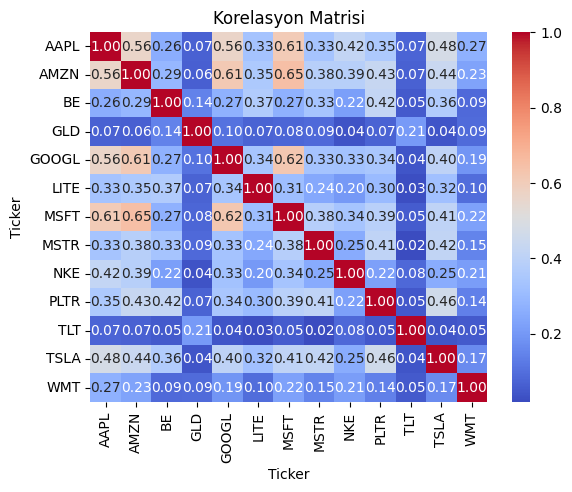

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = log_returns.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.show()

###Backtest

[*********************100%***********************]  1 of 1 completed


Start date,2020-10-02
End date,2026-04-02
Total months,65
,Backtest
Annual return,27.922%
Cumulative returns,285.55%
Annual volatility,19.979%
Sharpe ratio,1.33
Calmar ratio,0.81
Stability,0.57
Max drawdown,-34.382%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,34.38,2021-11-05,2022-12-28,2024-05-16,660
1,22.33,2025-02-06,2025-04-08,2025-06-24,99
2,11.89,2021-02-09,2021-03-08,2021-08-12,133
3,11.63,2024-07-16,2024-08-07,2024-08-23,29
4,10.58,2026-03-02,2026-03-30,NaT,NaN


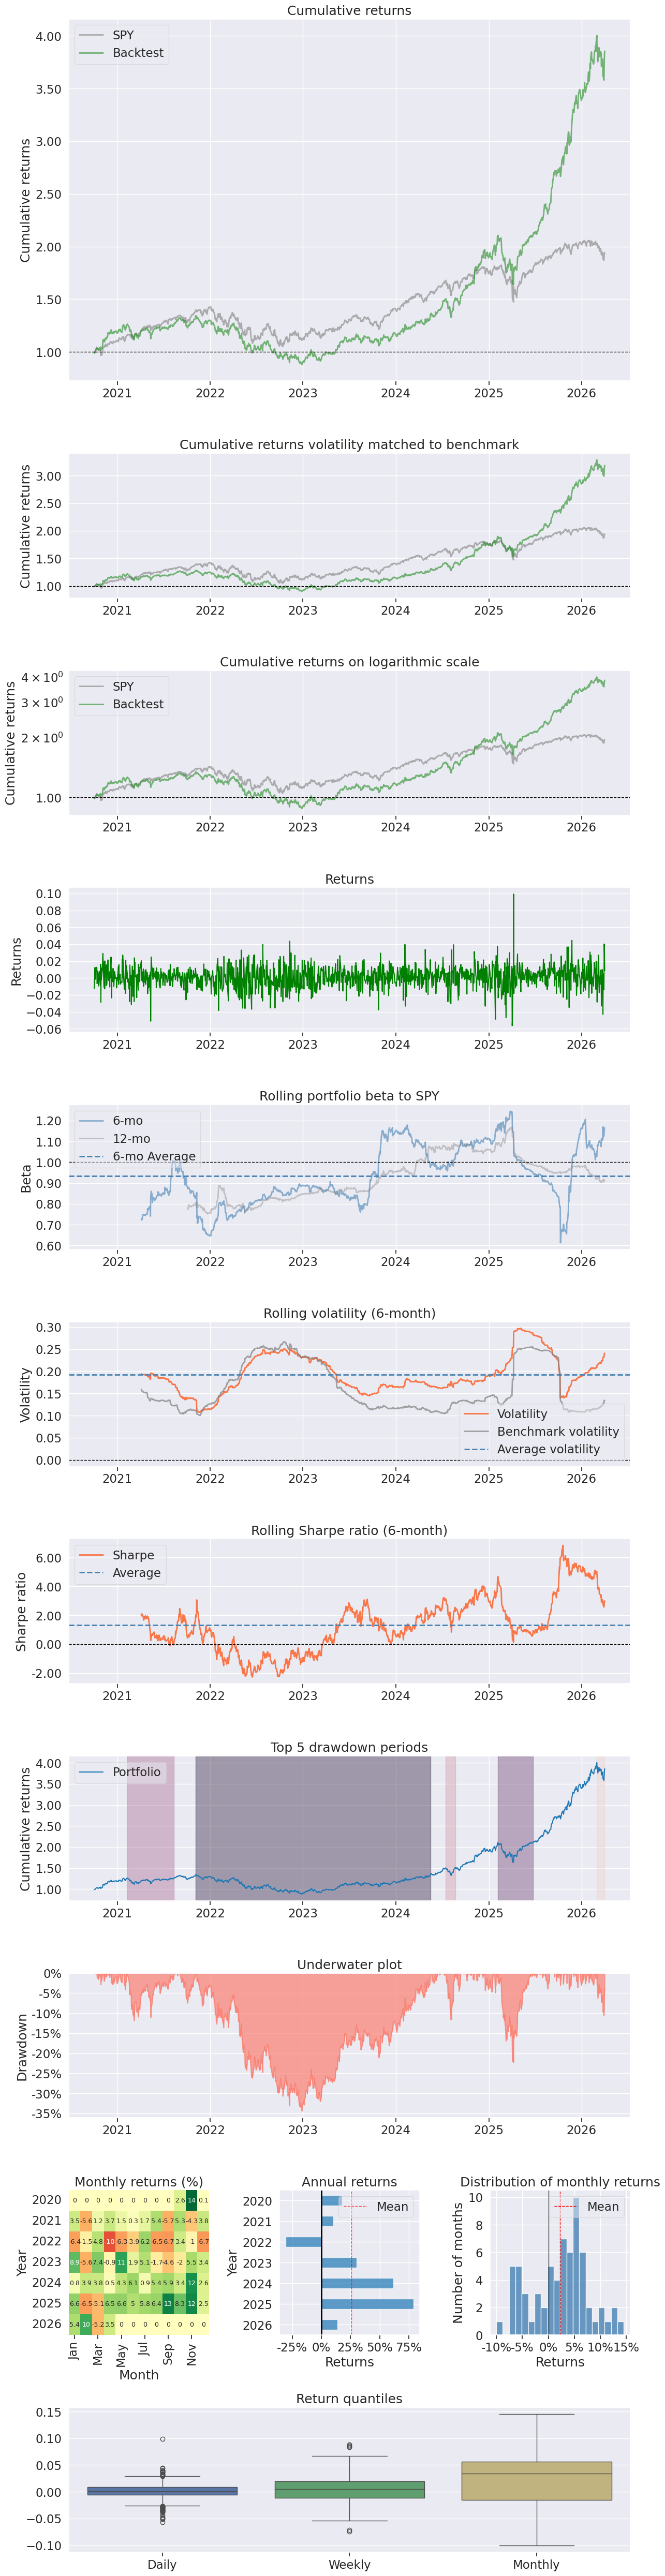

In [44]:
import pyfolio as pf

portfolio_returns = (log_returns * optimal_weights).sum(axis=1)
spy = yf.download("SPY", start=log_returns.index[0])["Close"]
benchmark_returns = np.log(spy / spy.shift(1)).dropna().squeeze()

pf.create_full_tear_sheet(
    portfolio_returns,
    benchmark_rets=benchmark_returns
)


###Monte Carlo Simulation

In [45]:
iteration=1000
days=252
values=[]
scenarios=[]

portfolio_returns = (log_returns * optimal_weights).sum(axis=1)
mean_portfolio_returns = portfolio_returns.mean()
volatility = portfolio_returns.std()

for i in range(0,iteration):
   value=1
   path=[]
   for j in range(0,days):
      z_score=np.random.normal(0,1)
      random_return=mean_portfolio_returns + volatility * z_score
      value=value*np.exp(random_return)
      path.append(value)
   scenarios.append(path)

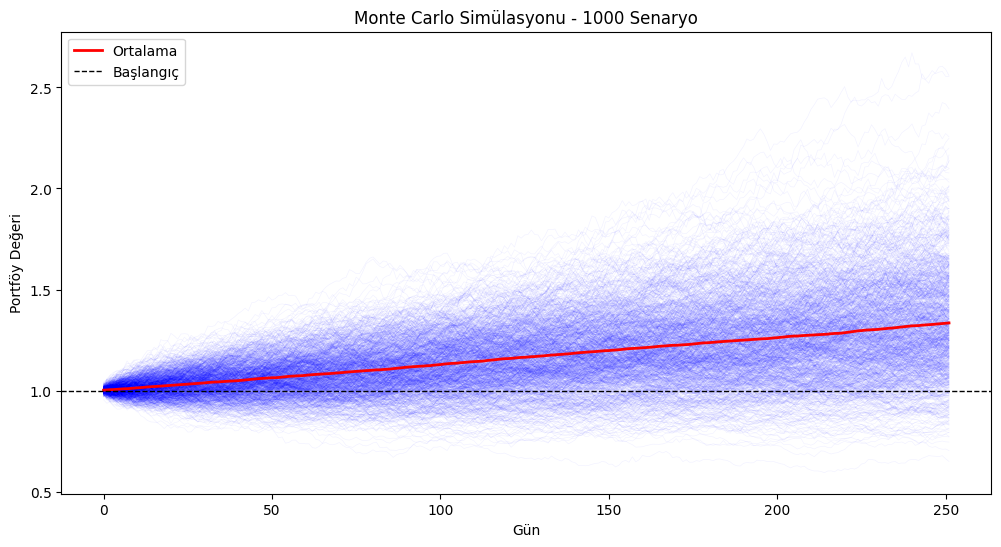

In [46]:
import matplotlib.pyplot as plt
import numpy as np

scenarios_array = np.array(scenarios)

plt.figure(figsize=(12, 6))
plt.plot(scenarios_array.T, alpha=0.05, color='blue', linewidth=0.5)
plt.plot(scenarios_array.mean(axis=0), color='red', linewidth=2, label='Ortalama')
plt.axhline(y=1, color='black', linestyle='--', linewidth=1, label='Başlangıç')
plt.xlabel("Gün")
plt.ylabel("Portföy Değeri")
plt.title("Monte Carlo Simülasyonu - 1000 Senaryo")
plt.legend()
plt.show()

In [47]:
final_values = scenarios_array[:, -1]

print(f"Ortalama: {final_values.mean():.2f}")
print(f"En iyi %5: {np.percentile(final_values, 95):.2f}")
print(f"En kötü %5: {np.percentile(final_values, 5):.2f}")
print(f"Kayıp olasılığı: {(final_values < 1).mean():.1%}")

Ortalama: 1.33
En iyi %5: 1.81
En kötü %5: 0.93
Kayıp olasılığı: 9.1%
